In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
import pickle
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

%matplotlib inline

print("All imports loaded successfully.")

All imports loaded successfully.


In [5]:
X_train = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\AI_PROJECT\X_train.csv")
X_test = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\AI_PROJECT\X_test.csv")
y_train = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\AI_PROJECT\y_train.csv").values.ravel()
y_test = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\AI_PROJECT\y_test.csv").values.ravel()

In [6]:
results = {}  # store metrics for comparison

def evaluate(name, pipeline, X_test, y_test):
    """Evaluate a trained pipeline and store results."""
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1": f1_score(y_test, y_pred, average="weighted"),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }
    results[name] = metrics
    return metrics, y_pred, y_proba

In [7]:

with open(r"C:\Users\LENOVO\OneDrive\Desktop\AI_PROJECT\preprocessor.pkl", "rb") as f:
    preprocessor = pickle.load(f)
print("Preprocessor loaded ✅")

Preprocessor loaded ✅


In [8]:
# Baseline
lr_base = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])
lr_base.fit(X_train, y_train)
lr_base_metrics, _, _ = evaluate("Logistic (Baseline)", lr_base, X_test, y_test)
print("Logistic Regression — Baseline")
for k, v in lr_base_metrics.items():
    print(f"  {k}: {v:.4f}")


Logistic Regression — Baseline
  Accuracy: 0.8125
  Precision: 0.7969
  Recall: 0.8125
  F1: 0.7949
  ROC-AUC: 0.8204


In [9]:
lr_grid = GridSearchCV(
    estimator=Pipeline([
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(max_iter=2000))
    ]),
    param_grid={
        "model__C": [0.01, 0.1, 1, 10],
        "model__penalty": ["l2"],
        "model__class_weight": ["balanced", None]
    },
    cv=5, scoring="roc_auc", n_jobs=-1
)
lr_grid.fit(X_train, y_train)
lr_tuned = lr_grid.best_estimator_
print(f"Best params: {lr_grid.best_params_}")

lr_tuned_metrics, _, _ = evaluate("Logistic (Tuned)", lr_tuned, X_test, y_test)
print("\nLogistic Regression — Tuned")
for k, v in lr_tuned_metrics.items():
    print(f"  {k}: {v:.4f}")

Best params: {'model__C': 0.01, 'model__class_weight': None, 'model__penalty': 'l2'}

Logistic Regression — Tuned
  Accuracy: 0.8140
  Precision: 0.7989
  Recall: 0.8140
  F1: 0.7941
  ROC-AUC: 0.8212


In [10]:
rf_base = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])
rf_base.fit(X_train, y_train)
rf_base_metrics, _, _ = evaluate("Random Forest (Baseline)", rf_base, X_test, y_test)
print("Random Forest — Baseline")
for k, v in rf_base_metrics.items():
    print(f"  {k}: {v:.4f}")

Random Forest — Baseline
  Accuracy: 0.8015
  Precision: 0.7826
  Recall: 0.8015
  F1: 0.7818
  ROC-AUC: 0.7988


In [11]:
rf_grid = GridSearchCV(
    estimator=Pipeline([
        ("preprocessing", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]),
    param_grid={
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
        "model__class_weight": ["balanced"]
    },
    cv=5, scoring="roc_auc", n_jobs=-1
)
rf_grid.fit(X_train, y_train)
rf_tuned = rf_grid.best_estimator_
print(f"Best params: {rf_grid.best_params_}")

rf_tuned_metrics, _, _ = evaluate("Random Forest (Tuned)", rf_tuned, X_test, y_test)
print("\nRandom Forest — Tuned")
for k, v in rf_tuned_metrics.items():
    print(f"  {k}: {v:.4f}")

Best params: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 400}

Random Forest — Tuned
  Accuracy: 0.7765
  Precision: 0.8043
  Recall: 0.7765
  F1: 0.7860
  ROC-AUC: 0.8086


In [12]:
xgb_base = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(eval_metric="auc", random_state=42))
])
xgb_base.fit(X_train, y_train)
xgb_base_metrics, _, _ = evaluate("XGBoost (Baseline)", xgb_base, X_test, y_test)
print("XGBoost — Baseline")
for k, v in xgb_base_metrics.items():
    print(f"  {k}: {v:.4f}")

XGBoost — Baseline
  Accuracy: 0.7890
  Precision: 0.7704
  Recall: 0.7890
  F1: 0.7745
  ROC-AUC: 0.7756


In [16]:
xgb_search = RandomizedSearchCV(
    estimator=Pipeline([
        ("preprocessing", preprocessor),
        ("model", XGBClassifier(eval_metric="auc", random_state=42))
    ]),
    param_distributions={
        "model__n_estimators": [500, 800],
        "model__max_depth": [6, 8, 10],
        "model__learning_rate": [0.01, 0.03],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    },
    n_iter=15, cv=5, scoring="roc_auc",
    n_jobs=-1, random_state=42
)
xgb_search.fit(X_train, y_train)
xgb_tuned = xgb_search.best_estimator_
print(f"Best params: {xgb_search.best_params_}")

xgb_tuned_metrics, _, _ = evaluate("XGBoost (Tuned)", xgb_tuned, X_test, y_test)
print("\nXGBoost — Tuned")
for k, v in xgb_tuned_metrics.items():
    print(f"  {k}: {v:.4f}")

Best params: {'model__subsample': 0.8, 'model__n_estimators': 500, 'model__max_depth': 6, 'model__learning_rate': 0.01, 'model__colsample_bytree': 1.0}

XGBoost — Tuned
  Accuracy: 0.8085
  Precision: 0.7919
  Recall: 0.8085
  F1: 0.7908
  ROC-AUC: 0.8081


In [17]:
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values("ROC-AUC", ascending=False)
results_df.style.highlight_max(axis=0, color="#c6efce")

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic (Tuned),0.814000,0.798900,0.814000,0.794100,0.821200
Logistic (Baseline),0.812500,0.796900,0.812500,0.794900,0.820400
Random Forest (Tuned),0.776500,0.804300,0.776500,0.786000,0.808600
XGBoost (Tuned),0.808500,0.791900,0.808500,0.790800,0.808100
Random Forest (Baseline),0.801500,0.782600,0.801500,0.781800,0.798800
XGBoost (Baseline),0.789000,0.770400,0.789000,0.774500,0.775600


In [18]:
best_name = results_df["ROC-AUC"].idxmax()
best_pipeline = {
    "Logistic (Baseline)": lr_base,
    "Logistic (Tuned)": lr_tuned,
    "Random Forest (Baseline)": rf_base,
    "Random Forest (Tuned)": rf_tuned,
    "XGBoost (Baseline)": xgb_base,
    "XGBoost (Tuned)": xgb_tuned
}[best_name]
print(f"Best model: {best_name} (ROC-AUC = {results_df.loc[best_name, 'ROC-AUC']:.4f})")

Best model: Logistic (Tuned) (ROC-AUC = 0.8212)


In [19]:
with open("model.pkl", "wb") as f:
    pickle.dump(best_pipeline, f)

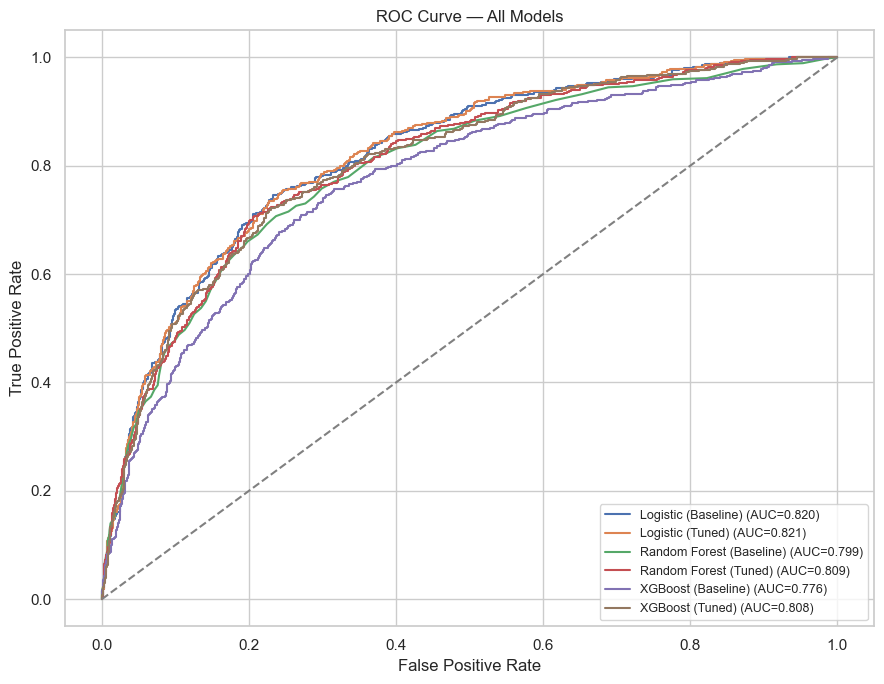

In [20]:
# ROC curves — all models
pipelines = {
    "Logistic (Baseline)": lr_base,
    "Logistic (Tuned)": lr_tuned,
    "Random Forest (Baseline)": rf_base,
    "Random Forest (Tuned)": rf_tuned,
    "XGBoost (Baseline)": xgb_base,
    "XGBoost (Tuned)": xgb_tuned
}

plt.figure(figsize=(9, 7))
for name, pipe in pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — All Models")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


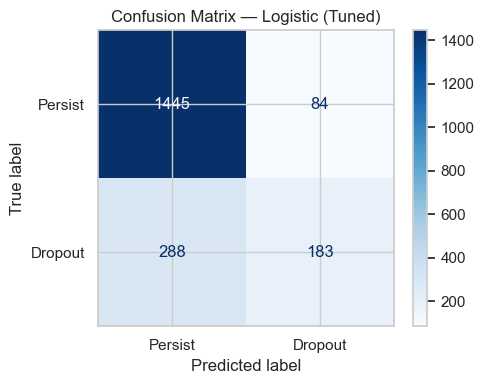

In [21]:
# Confusion matrix for the best model
y_pred_best = best_pipeline.predict(X_test)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=["Persist", "Dropout"],
    cmap="Blues", ax=ax
)
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

In [22]:
# Classification report for the best model
print(f"Classification Report — {best_name}\n")
print(classification_report(y_test, y_pred_best, target_names=["Persist", "Dropout"]))


Classification Report — Logistic (Tuned)

              precision    recall  f1-score   support

     Persist       0.83      0.95      0.89      1529
     Dropout       0.69      0.39      0.50       471

    accuracy                           0.81      2000
   macro avg       0.76      0.67      0.69      2000
weighted avg       0.80      0.81      0.79      2000



In [23]:

X = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\AI_PROJECT\X.csv")
y = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\AI_PROJECT\y.csv").values.ravel()

print("X and y loaded ✅")

X and y loaded ✅


In [25]:
best_model = best_pipeline.named_steps["model"]
best_preprocessor = best_pipeline.named_steps["preprocessing"]

X_processed = best_preprocessor.transform(X)
feature_names = best_preprocessor.get_feature_names_out()

model_name = type(best_model).__name__
print(f"Creating SHAP explainer for {model_name}...")

if model_name in ["RandomForestClassifier", "XGBClassifier"]:
    explainer = shap.TreeExplainer(best_model)
elif model_name == "LogisticRegression":
    explainer = shap.LinearExplainer(best_model, X_processed)
else:
    raise ValueError(f"Model {model_name} not supported for SHAP")

shap_values = explainer.shap_values(X_processed)
print("SHAP values computed.")

Creating SHAP explainer for LogisticRegression...
SHAP values computed.


In [26]:
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

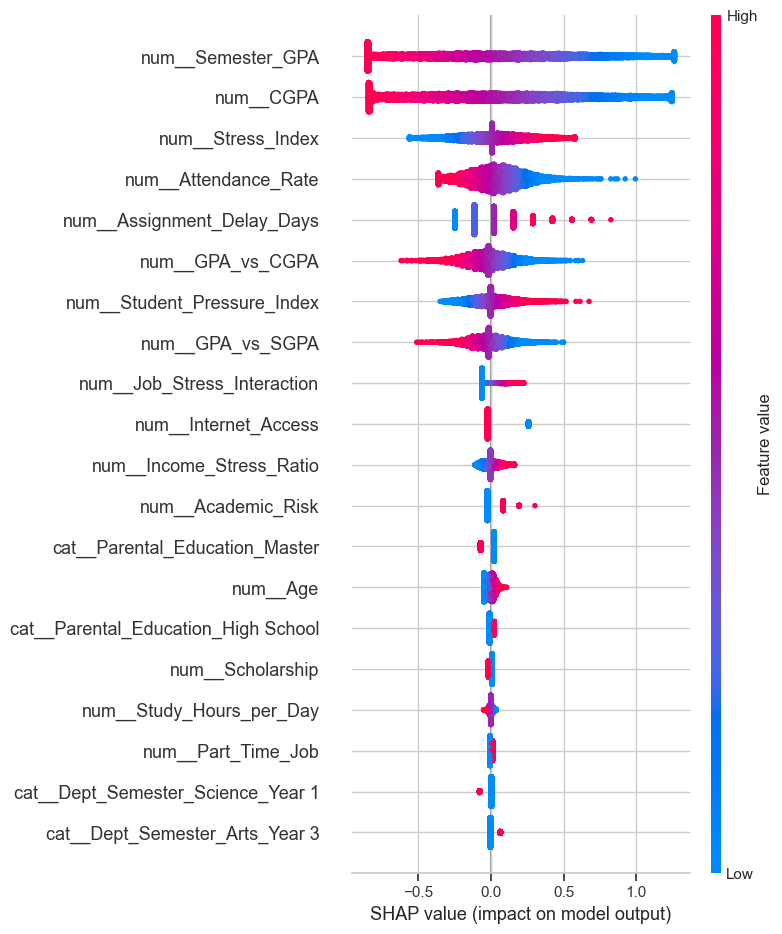

In [27]:
# Handle both SHAP output formats
if isinstance(shap_values, list):
    sv = shap_values[1]  # class 1 = Dropout
else:
    sv = shap_values

shap.summary_plot(sv, X_processed, feature_names=feature_names, show=True)

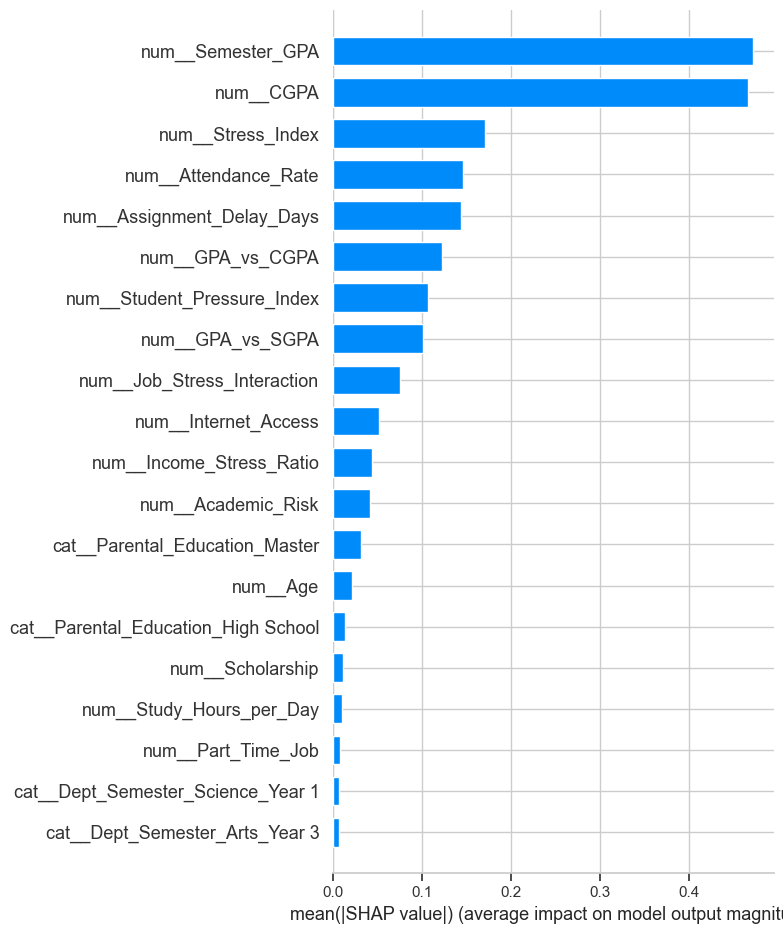

In [28]:
shap.summary_plot(sv, X_processed, feature_names=feature_names, plot_type="bar", show=True)

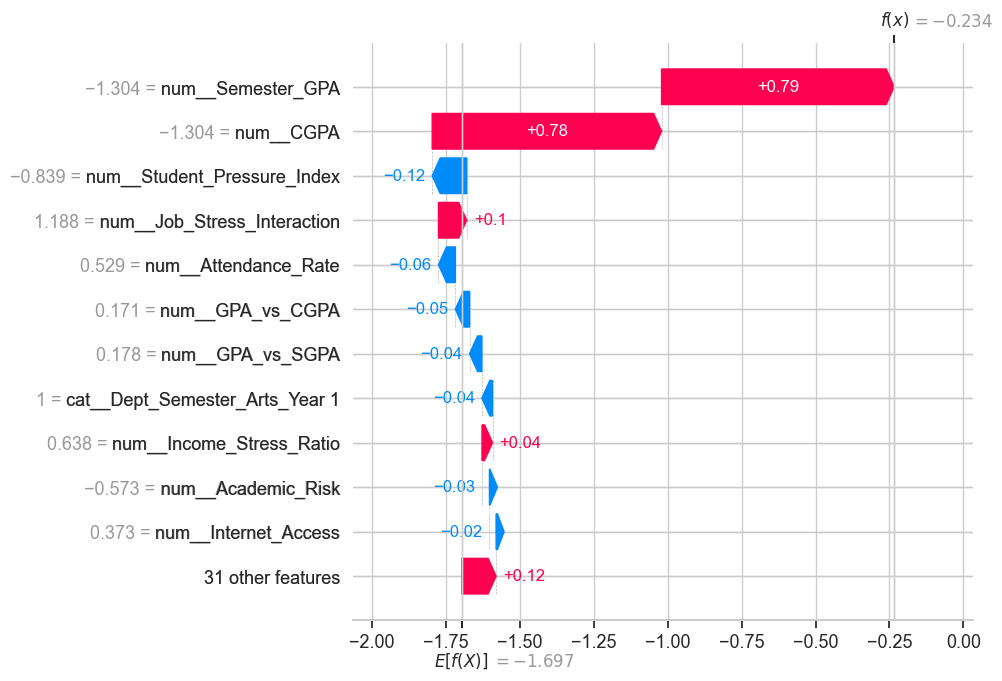


Actual label: Persist
Model prediction: Persist


In [29]:
student_idx = 0  # change this index to inspect different students

if isinstance(shap_values, list):
    student_shap = shap_values[1][student_idx]
    base_val = explainer.expected_value[1]
elif hasattr(shap_values, "ndim") and shap_values.ndim == 2:
    student_shap = shap_values[student_idx]
    base_val = explainer.expected_value
else:
    student_shap = shap_values[student_idx, :, 1]
    base_val = explainer.expected_value[1]

shap.waterfall_plot(
    shap.Explanation(
        values=student_shap,
        base_values=base_val,
        data=X_processed[student_idx],
        feature_names=feature_names
    ),
    max_display=12
)
print(f"\nActual label: {'Dropout' if y[student_idx] == 1 else 'Persist'}")
print(f"Model prediction: {'Dropout' if best_model.predict(X_processed[student_idx:student_idx+1])[0] == 1 else 'Persist'}")

In [30]:
# === Fill in student details here ===
new_student = {
    "Age": 21,
    "GPA": 2.8,
    "CGPA": 2.6,
    "Semester_GPA": 2.5,
    "Study_Hours_per_Day": 3.0,
    "Assignment_Delay_Days": 4,
    "Attendance_Rate": 70,
    "Travel_Time_Minutes": 30,
    "Family_Income": 30000,
    "Internet_Access": "Yes",
    "Scholarship": "No",
    "Part_Time_Job": "Yes",
    "Stress_Index": 6.5,
    "Semester": "Year 2",
    "Department": "Engineering",
    "Parental_Education": "High School"
}

In [31]:

# Build input dataframe with same feature engineering as training
input_df = pd.DataFrame([new_student])

# Binary encoding
for col in ["Internet_Access", "Scholarship", "Part_Time_Job"]:
    input_df[col] = input_df[col].map({"Yes": 1, "No": 0})

# Feature engineering (same as training)
input_df["Dept_Semester"] = input_df["Department"] + "_" + input_df["Semester"]
input_df["Income_Stress_Ratio"] = input_df["Stress_Index"] / (input_df["Family_Income"] + 1)
input_df["GPA_vs_CGPA"] = input_df["GPA"] - input_df["CGPA"]
input_df["GPA_vs_SGPA"] = input_df["GPA"] - input_df["Semester_GPA"]
input_df["Job_Stress_Interaction"] = input_df["Part_Time_Job"] * input_df["Stress_Index"]
input_df["Student_Pressure_Index"] = (
    input_df["Assignment_Delay_Days"] + input_df["Travel_Time_Minutes"]
    + input_df["Part_Time_Job"] + input_df["Stress_Index"]
) / (input_df["Attendance_Rate"] + input_df["Study_Hours_per_Day"] + 0.01)
input_df["Academic_Risk"] = (
    (input_df["Attendance_Rate"] < 75).astype(int)
    + (input_df["Study_Hours_per_Day"] < 2).astype(int)
    + (input_df["Assignment_Delay_Days"] > 5).astype(int)
)

# Drop same columns as training
input_df = input_df.drop(columns=["Department", "Semester", "Family_Income", "GPA"])

# Predict
prediction = best_pipeline.predict(input_df)[0]
proba = best_pipeline.predict_proba(input_df)[0]
confidence = proba[prediction] * 100

label = "Dropout" if prediction == 1 else "Persist"
risk_color = "\033[91m" if prediction == 1 else "\033[92m"
reset = "\033[0m"

print(f"Prediction: {risk_color}{label}{reset}")
print(f"Confidence: {confidence:.1f}%")
print(f"Probabilities: Persist={proba[0]:.3f}, Dropout={proba[1]:.3f}")

Prediction: Persist
Confidence: 72.4%
Probabilities: Persist=0.724, Dropout=0.276


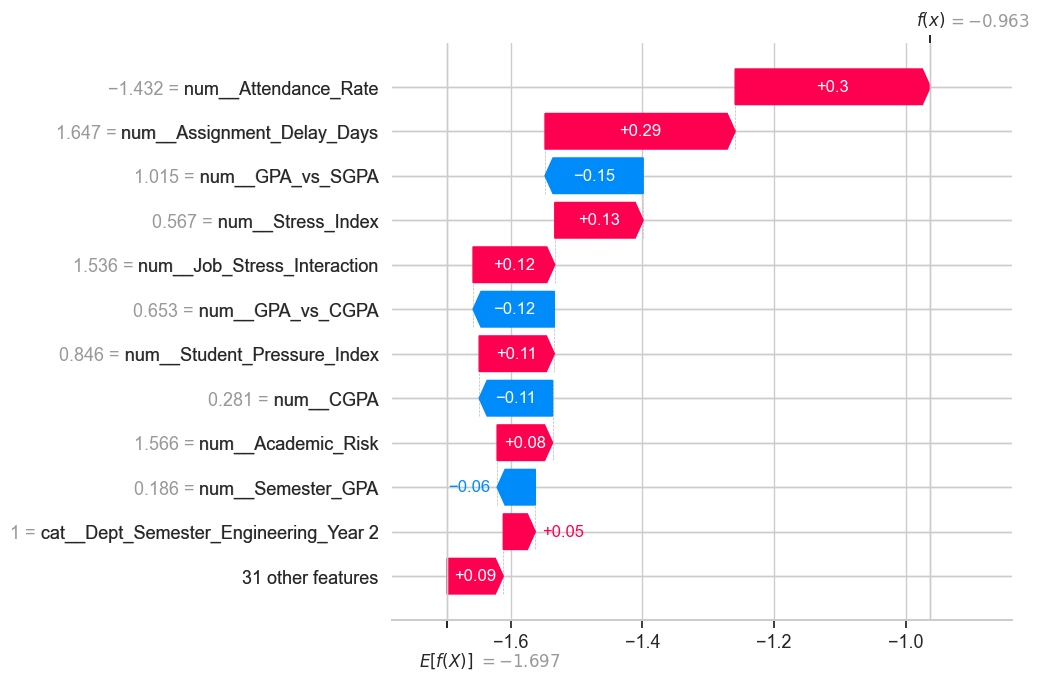


Top 5 factors influencing this prediction:
  num__Attendance_Rate: 0.2963
  num__Assignment_Delay_Days: 0.2886
  num__GPA_vs_SGPA: 0.1490
  num__Stress_Index: 0.1341
  num__Job_Stress_Interaction: 0.1241


In [32]:
# SHAP explanation for this student
input_processed = best_preprocessor.transform(input_df)

if model_name in ["RandomForestClassifier", "XGBClassifier"]:
    student_explainer = shap.TreeExplainer(best_model)
else:
    student_explainer = shap.LinearExplainer(best_model, X_processed)

student_shap_vals = student_explainer.shap_values(input_processed)

if isinstance(student_shap_vals, list):
    sv_student = student_shap_vals[1][0]
    bv = student_explainer.expected_value[1]
elif hasattr(student_shap_vals, "ndim") and student_shap_vals.ndim == 2:
    sv_student = student_shap_vals[0]
    bv = student_explainer.expected_value
else:
    sv_student = student_shap_vals[0, :, 1]
    bv = student_explainer.expected_value[1]

shap.waterfall_plot(
    shap.Explanation(
        values=sv_student,
        base_values=bv,
        data=input_processed[0],
        feature_names=feature_names
    ),
    max_display=12
)

# Top contributing features
importance = pd.Series(abs(sv_student), index=feature_names).sort_values(ascending=False).head(5)
print("\nTop 5 factors influencing this prediction:")
for feat, val in importance.items():
    print(f"  {feat}: {val:.4f}")